<a href="https://colab.research.google.com/github/MeghashreeGirish11/Handwriting-Recognition-AI/blob/main/TrOCR_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install transformers
%pip install torch torchvision
%pip install sentencepiece
%pip install pillow
import transformers
from transformers import TrOCRProcessor
from transformers import VisionEncoderDecoderModel

from PIL import Image
import matplotlib.pyplot as plt
import requests
import torch

In [ ]:

print(transformers.__version__)
processor = TrOCRProcessor.from_pretrained(
    "microsoft/trocr-base-handwritten"
)

model = VisionEncoderDecoderModel.from_pretrained(
    "microsoft/trocr-base-handwritten"
)

print("✅ TrOCR model loaded successfully!")
from google.colab import files

uploaded = files.upload()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.17k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ TrOCR model loaded successfully!


In [ ]:
%pip install transformers
%pip install sentencepiece
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

processor = TrOCRProcessor.from_pretrained(
    "microsoft/trocr-base-handwritten"
)

model = VisionEncoderDecoderModel.from_pretrained(
    "microsoft/trocr-base-handwritten"
)

print("✅ TrOCR model loaded successfully!")

True
Tesla T4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.17k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ TrOCR model loaded successfully!


In [ ]:
import torch

print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: Tesla T4


In [ ]:
%pip install transformers sentencepiece

In [ ]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

print("Loading processor...")
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")

print("Loading model...")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")

model = model.to("cuda")

print("✅ TrOCR model loaded successfully!")

Loading processor...
Loading model...


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ TrOCR model loaded successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 1000202258.jpg to 1000202258.jpg


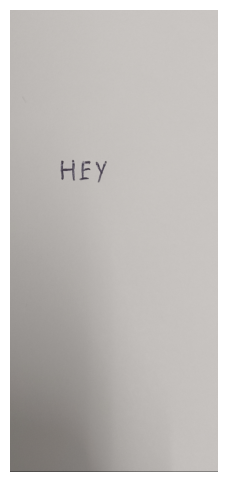

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(next(iter(uploaded))).convert("RGB")

plt.figure(figsize=(8,6))
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
pixel_values = processor(image, return_tensors="pt").pixel_values

pixel_values = pixel_values.to("cuda")

generated_ids = model.generate(pixel_values)

generated_text = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("Recognized Text:")
print(generated_text)

/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1616: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Recognized Text:
0 0


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving 1000202258.jpg to 1000202258 (1).jpg


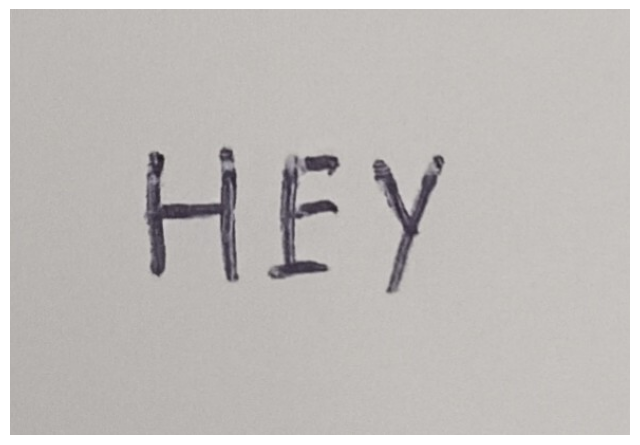

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(next(iter(uploaded))).convert("RGB")

plt.figure(figsize=(8,6))
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
pixel_values = processor(image, return_tensors="pt").pixel_values

pixel_values = pixel_values.to("cuda")

generated_ids = model.generate(pixel_values)

generated_text = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("Recognized Text:")
print(generated_text)

Recognized Text:
hey


In [ ]:
%pip install opencv-python

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

(np.float64(-0.5), np.float64(1275.5), np.float64(2843.5), np.float64(-0.5))

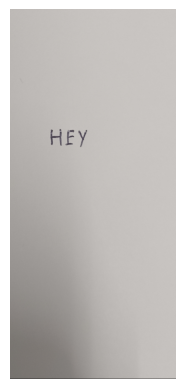

In [ ]:
img = cv2.imread("/content/1000202258.jpg")

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

In [ ]:
import os
print(os.listdir("/content"))

['.config', '1000202258 (1).jpg', '1000202258.jpg', 'sample_data']
